In [8]:
!conda uninstall -y pytorch torchvision
!pip uninstall -y torch torchvision torchaudio img2vec_pytorch

2 channel Terms of Service accepted

PackagesNotFoundError: The following packages are missing from the target environment:

  - torchvision
  - pytorch


Found existing installation: torch 2.14.0.dev20260804
Uninstalling torch-2.14.0.dev20260804:
  Successfully uninstalled torch-2.14.0.dev20260804
Found existing installation: torchvision 0.29.0.dev20260805
Uninstalling torchvision-0.29.0.dev20260805:
  Successfully uninstalled torchvision-0.29.0.dev20260805
Found existing installation: torchaudio 2.11.0.dev20260804
Uninstalling torchaudio-2.11.0.dev20260804:
  Successfully uninstalled torchaudio-2.11.0.dev20260804
Found existing installation: img2vec_pytorch 1.0.2
Uninstalling img2vec_pytorch-1.0.2:
  Successfully uninstalled img2vec_pytorch-1.0.2


In [9]:
!pip install "numpy<2.0.0"

In [10]:
!pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cpu

Looking in indexes: https://download.pytorch.org/whl/nightly/cpu
  Using cached https://download-r2.pytorch.org/whl/nightly/cpu/torch-2.14.0.dev20260805-cp313-cp313-macosx_14_0_arm64.whl.metadata (39 kB)
  Using cached https://download-r2.pytorch.org/whl/nightly/cpu/torchvision-0.29.0.dev20260805-cp313-cp313-macosx_14_0_arm64.whl.metadata (5.7 kB)
  Using cached https://download-r2.pytorch.org/whl/nightly/cpu/torchaudio-2.11.0.dev20260804-cp313-cp313-macosx_14_0_arm64.whl.metadata (7.4 kB)
  Using cached https://download-r2.pytorch.org/whl/nightly/cpu/torch-2.14.0.dev20260804-cp313-cp313-macosx_14_0_arm64.whl.metadata (39 kB)
Using cached https://download-r2.pytorch.org/whl/nightly/cpu/torchvision-0.29.0.dev20260805-cp313-cp313-macosx_14_0_arm64.whl (1.9 MB)
Using cached https://download-r2.pytorch.org/whl/nightly/cpu/torch-2.14.0.dev20260804-cp313-cp313-macosx_14_0_arm64.whl (125.1 MB)
Using cached https://download-r2.pytorch.org/whl/nightly/cpu/torchaudio-2.11.0.dev20260804-cp313-cp3

In [11]:
!pip install img2vec_pytorch

  Using cached img2vec_pytorch-1.0.2-py3-none-any.whl.metadata (6.4 kB)
Using cached img2vec_pytorch-1.0.2-py3-none-any.whl (8.0 kB)


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RadialProjection(nn.Module):
    def __init__(self, radius=1.0):
        super().__init__()
        self.radius = radius

    def forward(self, x):
        x_unit = F.normalize(x, p=2, dim=1, eps=1e-12)
        x_sphere = x_unit * self.radius
        
        return x_sphere

In [13]:
import torch
import torch.nn as nn
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import os

print("PyTorch version:", torch.__version__)

import torch
import torch.nn as nn
import torchvision.models as models

class CIFAR10ResNet18(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Đổi Stem để giữ lại feature map cho ảnh 32x32
        resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity()
        resnet.fc = nn.Identity()
        
        self.backbone = resnet
        
        # Bỏ đóng băng conv1, layer2, layer3 và layer4
        for name, param in self.backbone.named_parameters():
            if "conv1" in name or "layer2" in name or "layer3" in name or "layer4" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

    def forward(self, x):
        return self.backbone(x)

# Cấu hình thiết bị mps
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device đang sử dụng: {device}")

# Khởi tạo mô hình
model = CIFAR10ResNet18().to(device)

# ---------------------------------------------------------
# 2. Cấu hình Learning Rate chênh lệch (Differential LR)
# ---------------------------------------------------------
# Giả lập Classifier Head 
class DummyHyperbolicHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(512, 10) # Ví dụ phân loại 10 class CIFAR-10

    def forward(self, x):
        return self.fc(x)

head = DummyHyperbolicHead().to(device)

# Phân loại tham số của backbone để cài đặt LR chênh lệch
stem_params = []
layer2_params = []
layer34_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if "conv1" in name:
            stem_params.append(param)
        elif "layer2" in name:
            layer2_params.append(param)
        elif "layer3" in name or "layer4" in name:
            layer34_params.append(param)

# Thiết lập Optimizer: Phân tầng LR từ nông đến sâu
optimizer = torch.optim.Adam([
    {'params': stem_params, 'lr': 1e-5},         # LR cực nhỏ cho conv1
    {'params': layer2_params, 'lr': 3e-5},       # LR rất nhỏ cho layer 2
    {'params': layer34_params, 'lr': 1e-4},      # LR vừa cho layer 3 và 4
    {'params': head.parameters(), 'lr': 1e-3}    # LR lớn nhất cho Head
])

print("Đã thiết lập Optimizer với Differential Learning Rate thành công.")

# ---------------------------------------------------------
# 3. Tự động tải và đọc CIFAR-10 bằng PyTorch
# ---------------------------------------------------------
data_dir = "/Users/ngoanhtu/Desktop/Experiment on cifar-10/data"

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.CIFAR10(root=data_dir, train=True, download=True, transform=transform)

# ---------------------------------------------------------
# 4. Trích xuất thử và mô phỏng Forward Pass
# ---------------------------------------------------------
model.train() # Chuyển sang train mode vì giờ đã mở khóa layer3, layer4
head.train()

sample_image, sample_label = train_dataset[0]
sample_image = sample_image.unsqueeze(0).to(device)

# Forward pass
features = model(sample_image)
outputs = head(features)

print(f"\nKích thước feature vector (Backbone): {features.shape}")
print(f"Kích thước output (Head): {outputs.shape}")

PyTorch version: 2.14.0.dev20260802
Device đang sử dụng: mps
Đã thiết lập Optimizer với Differential Learning Rate thành công.

Kích thước feature vector (Backbone): torch.Size([1, 512])
Kích thước output (Head): torch.Size([1, 10])


/opt/anaconda3/envs/ML_study/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(



--- ĐANG TRÍCH XUẤT 500 ĐẶC TRƯNG ĐỂ CHẠY PCA & PGA ---


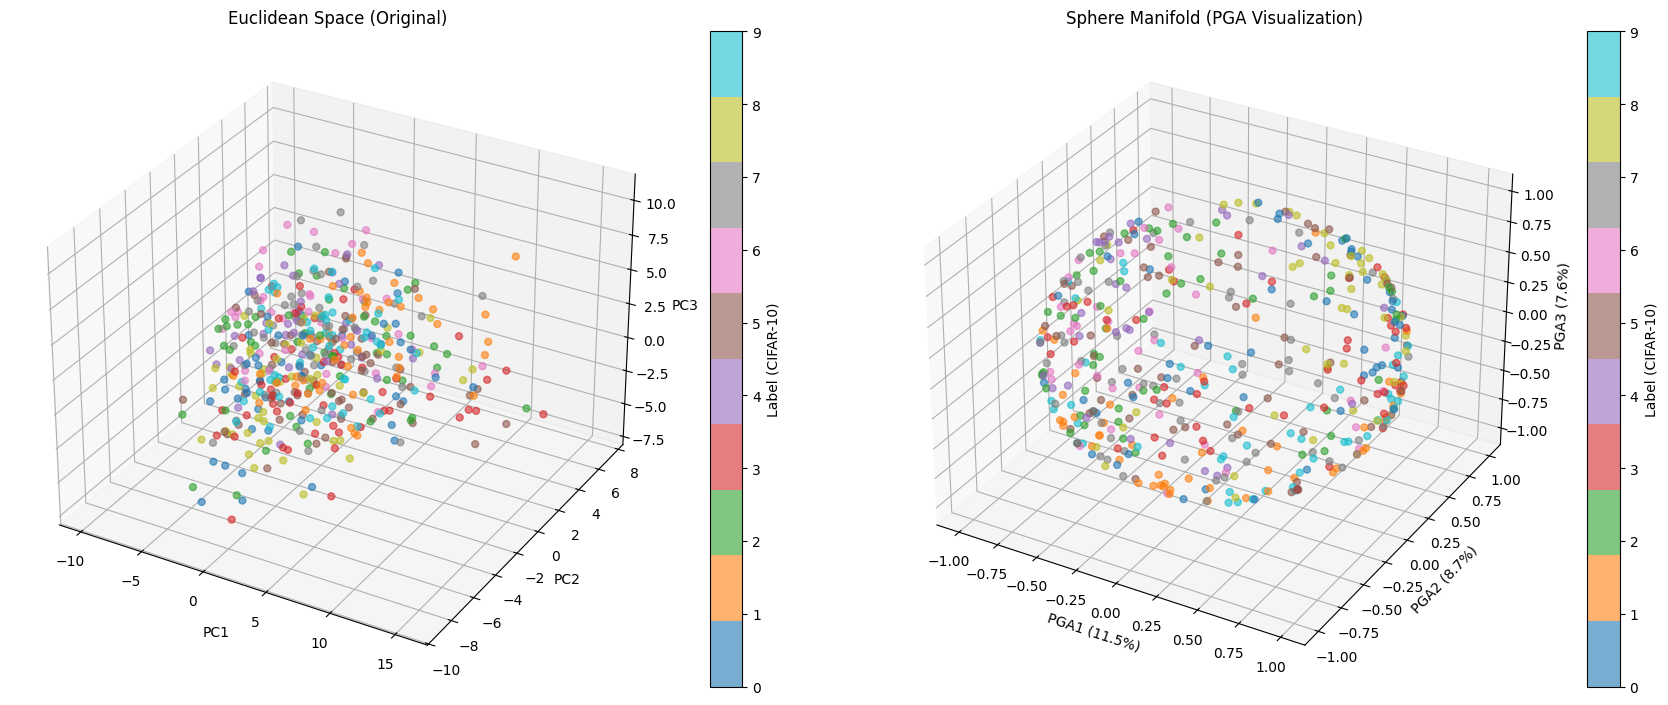


--- PHÂN TÍCH PHƯƠNG SAI (VARIANCE EXPLAINED) ---
Không gian Euclidean : 31.93% phương sai được giữ lại bởi 3 PCs đầu tiên.
Không gian Mặt cầu (PGA): 27.78% phương sai được giữ lại bởi 3 Principal Geodesics.
Mean Geodesic Reconstruction Error : 0.495752


In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- Thư viện bổ sung cho PGA ---
import geoopt
from geoopt import ManifoldParameter
from geoopt.manifolds.sphere import Sphere
import torch.nn.functional as F

# TRÍCH XUẤT ĐẶC TRƯNG
num_samples = 500
raw_features = []
labels = []

print(f"\n--- ĐANG TRÍCH XUẤT {num_samples} ĐẶC TRƯNG ĐỂ CHẠY PCA & PGA ---")

# Bật chế độ đánh giá cho mô hình
model.eval()

# Lấy ngẫu nhiên 500 ảnh
indices = np.random.choice(len(train_dataset), num_samples, replace=False)

with torch.no_grad():
    for i in indices:
        img, lbl = train_dataset[i]
        
        # Thêm chiều batch và đẩy ảnh lên thiết bị (mps/cpu)
        img = img.unsqueeze(0).to(device)

        # Trích xuất vector đặc trưng từ backbone và loại bỏ chiều dư thừa
        vec = model(img).squeeze()

        raw_features.append(vec)
        labels.append(lbl)

# Tensor [500, 512] - Đang nằm trên mps
raw_features_tensor = torch.stack(raw_features)

# CHIẾU LÊN MẶT CẦU
sphere_features_tensor = F.normalize(raw_features_tensor, p=2, dim=1, eps=1e-12)

# Đẩy dữ liệu về CPU để đảm bảo tương thích hoàn toàn với thư viện geoopt và numpy
raw_features_cpu = raw_features_tensor.detach().cpu()
sphere_features_cpu = sphere_features_tensor.detach().cpu()

# Chuyển sang NumPy
raw_np = raw_features_cpu.numpy()
sphere_np = sphere_features_cpu.numpy()

# PCA CHO KHÔNG GIAN EUCLIDEAN
pca_euclid = PCA(n_components=3)
euclidean_3d = pca_euclid.fit_transform(raw_np)

# SPHERE -> PRINCIPAL GEODESIC ANALYSIS (PGA)
sphere = Sphere()
sphere_points = sphere.projx(sphere_features_cpu.float())

# Fréchet Mean
mean_init = sphere.projx(
    sphere_points.mean(dim=0, keepdim=True)
)
frechet_mean = ManifoldParameter(
    mean_init.clone(),
    manifold=sphere
)
optimizer = geoopt.optim.RiemannianAdam(
    [frechet_mean],
    lr=0.05
)

for _ in range(200):
    optimizer.zero_grad()
    loss = sphere.dist(
        frechet_mean,
        sphere_points
    ).square().mean()
    loss.backward()
    optimizer.step()

frechet_mean = sphere.projx(
    frechet_mean.detach()
)

# Log Map
base_point = frechet_mean.repeat(
    sphere_points.size(0),
    1
)
tangent_vectors = sphere.logmap(
    base_point,
    sphere_points
)
tangent_vectors = sphere.proju(
    base_point,
    tangent_vectors
)

# PGA
_, singular_values, principal_directions = torch.pca_lowrank(
    tangent_vectors,
    q=3,
    center=True,
    niter=10
)
pga_3d = tangent_vectors @ principal_directions

# Tính tổng phương sai của toàn bộ 512 chiều tangent space
tangent_centered = tangent_vectors - tangent_vectors.mean(dim=0, keepdim=True)
total_variance = tangent_centered.square().sum()

explained_ratio = (
    singular_values.square()
    /
    total_variance
)

# Reconstruction (Evaluation)
tangent_reconstruction = (
    pga_3d @ principal_directions.T
)
sphere_reconstruction = sphere.expmap(
    base_point,
    tangent_reconstruction
)
mean_geodesic_error = sphere.dist(
    sphere_points,
    sphere_reconstruction
).mean()

# Visualization only
R_vis = 1.0
pga_3d_sphere = (
    F.normalize(
        pga_3d,
        dim=1
    ) * R_vis
)
pga_np = pga_3d_sphere.numpy()

# VẼ BIỂU ĐỒ
fig = plt.figure(figsize=(18, 7))

# Euclidean 
ax1 = fig.add_subplot(121, projection='3d')

sc1 = ax1.scatter(
    euclidean_3d[:, 0],
    euclidean_3d[:, 1],
    euclidean_3d[:, 2],
    c=labels,
    cmap='tab10',
    alpha=0.6,
    s=25
)

ax1.set_title("Euclidean Space (Original)")
ax1.set_xlabel("PC1")
ax1.set_ylabel("PC2")
ax1.set_zlabel("PC3")

plt.colorbar(sc1, ax=ax1, label="Label (CIFAR-10)")

# Sphere
ax2 = fig.add_subplot(122, projection='3d')

sc2 = ax2.scatter(
    pga_np[:, 0],
    pga_np[:, 1],
    pga_np[:, 2],
    c=labels,
    cmap='tab10',
    alpha=0.6,
    s=25
)

ax2.set_title("Sphere Manifold (PGA Visualization)")
ax2.set_xlabel(f"PGA1 ({explained_ratio[0]*100:.1f}%)")
ax2.set_ylabel(f"PGA2 ({explained_ratio[1]*100:.1f}%)")
ax2.set_zlabel(f"PGA3 ({explained_ratio[2]*100:.1f}%)")

plt.colorbar(sc2, ax=ax2, label="Label (CIFAR-10)")

plt.tight_layout()
plt.show()

# PHÂN TÍCH PHƯƠNG SAI
euclid_variance = np.sum(pca_euclid.explained_variance_ratio_) * 100
sphere_variance = (
    explained_ratio.sum().item() * 100
)

print("\n--- PHÂN TÍCH PHƯƠNG SAI (VARIANCE EXPLAINED) ---")
print(f"Không gian Euclidean : {euclid_variance:.2f}% phương sai được giữ lại bởi 3 PCs đầu tiên.")
print(f"Không gian Mặt cầu (PGA): {sphere_variance:.2f}% phương sai được giữ lại bởi 3 Principal Geodesics.")
print(f"Mean Geodesic Reconstruction Error : {mean_geodesic_error.item():.6f}")

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import geoopt
from sklearn.cluster import KMeans
import numpy as np


class AdvancedSphericalClassifier(nn.Module):
    def __init__(self, num_classes=10, num_prototypes=3, feature_dim=512):
        super().__init__()
        self.num_classes = num_classes
        self.num_prototypes = num_prototypes
        self.feature_dim = feature_dim

        # --- TÁI SỬ DỤNG CLASS TRÍCH XUẤT ĐẶC TRƯNG ---
        # Khởi tạo instance từ class CIFAR10ResNet18 bạn đã viết ở trên
        feature_extractor = CIFAR10ResNet18()
        self.backbone = feature_extractor.backbone

        # --- Learnable Parameters ---
        self.raw_temperature = nn.Parameter(torch.tensor([0.1]))

        # Giới hạn mềm alpha [1.0, 12.0]
        self.alpha_min = 1.0
        self.alpha_max = 12.0
        self.raw_alpha = nn.Parameter(torch.tensor([1.5041]))

        # Prototype Weights (w_ck)
        self.proto_weights = nn.Parameter(torch.ones(num_classes, num_prototypes))

        # --- Manifold & Prototypes ---
        self.manifold = geoopt.Sphere()
        init_p = F.normalize(torch.randn(num_classes, num_prototypes, feature_dim), p=2, dim=-1)
        self.prototypes = geoopt.ManifoldParameter(init_p, manifold=self.manifold)

    @property
    def temperature(self):
        return F.softplus(self.raw_temperature) + 1e-6

    @property
    def alpha(self):
        return self.alpha_min + (self.alpha_max - self.alpha_min) * torch.sigmoid(self.raw_alpha)

    def _rspe_pytorch(self, X, lam=1.0, rspe_alpha=1.0, q=0.90, eta=0.5, eps=1e-6, max_iter=200):
        """
        Thuật toán RSPE viết bằng PyTorch để chạy trực tiếp trên GPU.
        X: tensor (N, D) chứa các đặc trưng đã chuẩn hóa trên mặt cầu.
        """
        # Khởi tạo bằng Extrinsic Mean
        p = F.normalize(X.mean(dim=0), p=2, dim=0)

        for _ in range(max_iter):
            # 1. Geodesic Distance (Sử dụng arcsin để ổn định số học)
            diff_norm = torch.norm(X - p.unsqueeze(0), dim=-1)
            half_chord = torch.clamp(diff_norm / 2.0, min=0.0, max=1.0)
            d = 2.0 * torch.asin(half_chord)

            # 2. Distance Reliability
            R = torch.exp(-lam * (d ** 2))
            w = R / (R.sum() + 1e-12)

            # 3. Adaptive Soft Trim
            c = torch.quantile(d, q)
            if c < 1e-12: 
                c = torch.tensor(1e-12, device=X.device)

            T = torch.ones_like(d)
            mask = d > c
            T[mask] = torch.exp(-rspe_alpha * (((d[mask] - c) / c) ** 2))

            # 4. Final Reliability Weight
            w_hat = w * T
            w_hat = w_hat / (w_hat.sum() + 1e-12)

            # 5. Riemannian Gradient via Log Map
            # Mở rộng p thành (N, D) để tính logmap cho từng điểm x_i
            p_expanded = p.unsqueeze(0).expand_as(X)
            logs = self.manifold.logmap(p_expanded, X)
            grad = -2.0 * (w_hat.unsqueeze(1) * logs).sum(dim=0)

            # 6. Update bằng Exponential Map
            p_new = self.manifold.expmap(p, -eta * grad)
            p_new = F.normalize(p_new, p=2, dim=0)  # Chuẩn hóa an toàn về norm=1

            # 7. Check Hội Tụ
            delta_diff = torch.norm(p_new - p)
            delta = 2.0 * torch.asin(torch.clamp(delta_diff / 2.0, min=0.0, max=1.0))
            
            p = p_new
            if delta < eps:
                break
                
        return self.manifold.projx(p)

    def init_prototypes_from_data(self, dataloader, device, lam=1.0, rspe_alpha=1.0, q=0.90):
        """
        Khởi tạo Prototype sử dụng kết hợp KMeans (để phân cụm nếu K > 1) 
        và RSPE (để tìm trung tâm cụm chống nhiễu).
        """
        self.eval()
        print("Đang trích xuất đặc trưng để khởi tạo RSPE Prototypes...")

        all_features = []
        all_labels = []
        with torch.no_grad():
            for x, y in dataloader:
                x = x.to(device)
                feat = F.normalize(self.backbone(x), p=2, dim=1)
                all_features.append(feat.cpu())
                all_labels.append(y.cpu())

        all_features = torch.cat(all_features, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        new_prototypes = self.prototypes.detach().cpu().clone()

        for c in range(self.num_classes):
            X_c = all_features[all_labels == c]

            if len(X_c) < self.num_prototypes:
                continue

            # Bước 1: Log Map xuống tangent space để phân cụm KMeans (nhận diện các sub-cluster)
            frechet_mean = F.normalize(X_c.mean(dim=0, keepdim=True), p=2, dim=1)
            X_tangent = self.manifold.logmap(frechet_mean, X_c)
            X_tangent = torch.nan_to_num(X_tangent, nan=0.0, posinf=0.0, neginf=0.0)

            kmeans = KMeans(n_clusters=self.num_prototypes, n_init=10, random_state=42)
            cluster_labels = kmeans.fit_predict(X_tangent.cpu().numpy())

            # Bước 2: Chạy thuật toán RSPE cho dữ liệu của từng cụm k
            for k in range(self.num_prototypes):
                X_k = X_c[cluster_labels == k]
                
                if len(X_k) > 0:
                    # Gửi X_k sang device để tính toán RSPE bằng GPU, sau đó đẩy về CPU lưu tạm
                    p_k_robust = self._rspe_pytorch(X_k.to(device), lam=lam, rspe_alpha=rspe_alpha, q=q)
                    new_prototypes[c, k] = p_k_robust.cpu()
                else:
                    # Fallback nếu cụm rỗng (hiếm khi xảy ra với KMeans)
                    center_tangent = torch.tensor(kmeans.cluster_centers_[k], dtype=X_c.dtype)
                    center_sphere = self.manifold.expmap(frechet_mean[0], center_tangent)
                    new_prototypes[c, k] = self.manifold.projx(center_sphere)

        self.prototypes.data.copy_(new_prototypes.to(self.prototypes.device))
        print("Hoàn tất khởi tạo RSPE Prototypes!")
        self.train()

    def project_prototypes(self):
        """Giữ cho prototype luôn nằm trên manifold sau optimizer.step()"""
        with torch.no_grad():
            self.prototypes.data.copy_(self.manifold.projx(self.prototypes.data))

    def get_separation_loss(self):
        """
        Giữ nguyên hàm Separation Loss để tách xa các prototype trong quá trình train
        hoặc có thể được gọi tường minh ở pha tinh chỉnh sau khi train hội tụ.
        """
        cos_sim = torch.bmm(self.prototypes, self.prototypes.transpose(1, 2))
        cos_sim = torch.clamp(cos_sim, -1.0 + 1e-6, 1.0 - 1e-6)

        geodesic_dist = torch.acos(cos_sim)
        geodesic_dist = torch.clamp(geodesic_dist, min=1e-4)
        safe_alpha = torch.clamp(self.alpha, min=1.0, max=20.0)

        mask = torch.triu(torch.ones(self.num_prototypes, self.num_prototypes), diagonal=1)
        mask = mask.to(self.prototypes.device)
        mask = mask.unsqueeze(0).expand(self.num_classes, -1, -1)

        num_pairs = self.num_classes * self.num_prototypes * (self.num_prototypes - 1) / 2
        num_pairs = max(num_pairs, 1)
        
        l_sep = (torch.exp(-safe_alpha * geodesic_dist) * mask).sum() / num_pairs
        return l_sep

    def forward(self, x):
        feat = self.backbone(x)
        x_s = F.normalize(feat, p=2, dim=1, eps=1e-12)

        x_reshaped = x_s.unsqueeze(1).unsqueeze(1)    # (B, 1, 1, D)
        p_reshaped = self.prototypes.unsqueeze(0)     # (1, C, K, D)

        cos_sim = (x_reshaped * p_reshaped).sum(dim=-1)
        cos_sim = torch.clamp(cos_sim, -1.0 + 1e-6, 1.0 - 1e-6)
        d_ck = torch.acos(cos_sim)                    # (B, C, K)

        w = F.softplus(self.proto_weights)            # (C, K)
        w_reshaped = w.unsqueeze(0)                   # (1, C, K)

        scaled_term = torch.log(w_reshaped + 1e-9) - (self.alpha * d_ck)
        score_c = torch.logsumexp(scaled_term, dim=2) # (B, C)

        logits = score_c / self.temperature           # (B, C)
        sep_loss = self.get_separation_loss()

        return logits, sep_loss

In [16]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import geoopt

# ============================================================
# Device
# ============================================================
# Tối ưu hóa tự động chuyển sang phần cứng mps thay vì cuda
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# ============================================================
# Dataset
# ============================================================
batch_size = 64

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010),
    ),
    # Áp dụng RandomErasing để tăng cường dữ liệu mạnh mẽ hơn
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3))
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform_train,
)

trainloader_for_init = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

trainloader = trainloader_for_init

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.4914, 0.4822, 0.4465),
        (0.2023, 0.1994, 0.2010),
    ),
])

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform_test,
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

# Nếu cần lấy 1 batch từ testloader:
test_inputs, test_targets = next(iter(testloader))

# ============================================================
# Model
# ============================================================
model = AdvancedSphericalClassifier().to(device)

print("Initializing prototypes...")
model.init_prototypes_from_data(trainloader_for_init, device)

# ============================================================
# Loss
# ============================================================
criterion = nn.CrossEntropyLoss()

# Separation loss đã được chuẩn hoá theo số cặp; giữ trọng số nhỏ.
lambda_sep = 0.01

# ============================================================
# Optimizer
# ============================================================
optimizer = geoopt.optim.RiemannianAdam(
    [
        {
            "params": [model.prototypes],
            "lr": 1e-3,
        },
        {
            "params": [model.raw_temperature, model.proto_weights],
            "lr": 1e-4,
        },
        # Weight decay riêng kéo raw_alpha về 0 (alpha về giữa miền),
        # hạn chế xu hướng dính trần alpha_max.
        {"params": [model.raw_alpha], "lr": 1e-4, "weight_decay": 1e-3},
    ]
)

# ============================================================
# One Training Step (Debug)
# ============================================================
model.train()

inputs, targets = next(iter(trainloader))
inputs = inputs.to(device)
targets = targets.to(device)

optimizer.zero_grad()

logits, sep_loss = model(inputs)

ce_loss = criterion(logits, targets)

total_loss = ce_loss + lambda_sep * sep_loss

total_loss.backward()

optimizer.step()

# Project prototype back to Sphere
model.project_prototypes()

print("=" * 60)
print(f"CrossEntropy Loss : {ce_loss.item():.4f}")
print(f"Separation Loss   : {sep_loss.item():.4f}")
print(f"Total Loss        : {total_loss.item():.4f}")
print(f"Temperature       : {model.temperature.item():.4f}")
print(f"Alpha             : {model.alpha.item():.4f}")
print("=" * 60)

Using device: mps
Initializing prototypes...
Đang trích xuất đặc trưng để khởi tạo RSPE Prototypes...
Hoàn tất khởi tạo RSPE Prototypes!
CrossEntropy Loss : 2.2788
Separation Loss   : 0.0704
Total Loss        : 2.2795
Temperature       : 0.7443
Alpha             : 10.0002


In [17]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.transforms import v2

# ==========================================================
# CẤU HÌNH WARM-UP & PROGRESSIVE UNFREEZING
# ==========================================================
num_epochs = 100
warmup_epochs = 5
cooldown_epochs = 15
alpha_weight_decay = 1e-3

# Các mốc epoch chuyển stage (đều nằm gọn trước cool-down = epoch 85)
stage_epochs = {
    1: warmup_epochs,        # epoch 5:  unfreeze layer4
    2: 25,                   # epoch 25: + layer3
    3: 45,                   # epoch 45: + layer2
    4: 65,                   # epoch 65: + conv1, bn1
}
cooldown_start = num_epochs - cooldown_epochs  # epoch 85

cutmix = v2.CutMix(num_classes=10)
mixup = v2.MixUp(num_classes=10)
cutmix_or_mixup = v2.RandomChoice([cutmix, mixup])

# 1. Đóng băng toàn bộ backbone ban đầu cho giai đoạn Warm-up
for param in model.backbone.parameters():
    param.requires_grad = False

# 2. Optimizer lần 1 (chỉ train Head)
head_params = [p for name, p in model.named_parameters()
               if p.requires_grad and name != "raw_alpha"]

optimizer = torch.optim.Adam([
    {"params": head_params, "lr": 1e-3, "weight_decay": 1e-4},
    {"params": [model.raw_alpha], "lr": 1e-3, "weight_decay": alpha_weight_decay},
])
scheduler = None  # Chưa dùng scheduler trong lúc warm-up


def build_optimizer(model, stage):
    """
    Xây dựng lại optimizer theo stage hiện tại.
    LR giảm dần theo độ sâu: layer càng nông (gần input) LR càng nhỏ,
    vì layer nông vừa mới unfreeze, dễ bị 'phá' pretrained weight nếu học nhanh.
    """
    param_groups = []

    def add_group(name_filter, lr, wd=1e-4):
        params = [p for name, p in model.named_parameters()
                  if p.requires_grad and name_filter(name)]
        if params:
            param_groups.append({"params": params, "lr": lr, "weight_decay": wd})

    # Head (prototypes, proto_weights, raw_temperature) - luôn LR cao nhất
    add_group(lambda n: "backbone" not in n and n != "raw_alpha", lr=1e-3, wd=1e-4)

    # raw_alpha tách riêng vì có weight_decay khác
    add_group(lambda n: n == "raw_alpha", lr=1e-3, wd=alpha_weight_decay)

    # Backbone - LR theo độ sâu, chỉ add nếu layer đó đã unfreeze ở stage này
    if stage >= 1:
        add_group(lambda n: "backbone" in n and "layer4" in n, lr=1e-4)
    if stage >= 2:
        add_group(lambda n: "backbone" in n and "layer3" in n, lr=5e-5)
    if stage >= 3:
        add_group(lambda n: "backbone" in n and "layer2" in n, lr=2e-5)
    if stage >= 4:
        add_group(lambda n: n.startswith("backbone.conv1") or n.startswith("backbone.bn1"), lr=1e-5)

    return torch.optim.Adam(param_groups)


def unfreeze_stage(model, stage):
    """Mở khóa đúng phần backbone tương ứng với stage."""
    for name, param in model.backbone.named_parameters():
        if stage >= 1 and "layer4" in name:
            param.requires_grad = True
        if stage >= 2 and "layer3" in name:
            param.requires_grad = True
        if stage >= 3 and "layer2" in name:
            param.requires_grad = True
        if stage >= 4 and ("conv1" in name or "bn1" in name):
            param.requires_grad = True


# ==========================================================
# 4. End-to-End Training
# ==========================================================
print(f"--- BẮT ĐẦU WARM-UP {warmup_epochs} EPOCH ĐẦU TIÊN ---")

for epoch in range(num_epochs):

    # --- Cool-down: tắt CutMix/MixUp/RandomErasing + scheduler decay sâu ---
    if epoch == cooldown_start:
        print(f"\n[Chuyển pha] Bắt đầu Cool-down {cooldown_epochs} epoch cuối: "
              f"tắt CutMix, MixUp, RandomErasing và decay LR về gần 0...")
        for t in trainset.transform.transforms:
            if isinstance(t, transforms.RandomErasing):
                t.p = 0.0

        # Không đổi optimizer nữa (đã là stage 4 = full backbone),
        # chỉ cần 1 scheduler mới decay mượt về rất thấp trong đúng 15 epoch còn lại.
        scheduler = CosineAnnealingLR(optimizer, T_max=cooldown_epochs, eta_min=1e-6)

    # --- Progressive Unfreezing (chỉ áp dụng trước khi vào cool-down) ---
    current_lambda_sep = lambda_sep * (epoch + 1) / num_epochs

    for stage, start_epoch in stage_epochs.items():
        if epoch == start_epoch:
            print(f"\n[Chuyển pha] Stage {stage}: mở khóa thêm backbone, "
                  f"khởi tạo lại optimizer & scheduler...")
            unfreeze_stage(model, stage)
            optimizer = build_optimizer(model, stage)

            # T_max = số epoch còn lại tới mốc chuyển stage tiếp theo (hoặc tới cool-down)
            next_epochs = sorted(list(stage_epochs.values()) + [cooldown_start])
            future = [e for e in next_epochs if e > epoch]
            t_max = (future[0] - epoch) if future else cooldown_epochs

            scheduler = CosineAnnealingLR(optimizer, T_max=t_max, eta_min=1e-5)

    # Cập nhật chế độ Train/Eval cho Backbone
    model.train()
    if epoch < warmup_epochs:
        model.backbone.eval()  # Warmup: giữ BatchNorm ở eval
    else:
        model.backbone.train()

    train_loss = 0.0
    train_ce_loss = 0.0
    train_sep_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (inputs, targets) in enumerate(trainloader):

        inputs = inputs.to(device)
        targets = targets.to(device)

        if epoch < cooldown_start:
            inputs, targets = cutmix_or_mixup(inputs, targets)

        optimizer.zero_grad()

        logits, l_sep = model(inputs)
        ce_loss = criterion(logits, targets)
        loss = ce_loss + current_lambda_sep * l_sep

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        model.project_prototypes()

        train_loss += loss.item()
        train_ce_loss += ce_loss.item()
        train_sep_loss += l_sep.item()

        _, predicted = logits.max(dim=1)
        target_labels = targets if targets.dim() == 1 else targets.argmax(dim=1)
        total += target_labels.size(0)
        correct += predicted.eq(target_labels).sum().item()

        if batch_idx % 100 == 0:
            current_loss = train_loss / (batch_idx + 1)
            current_sep = train_sep_loss / (batch_idx + 1)
            current_acc = 100.0 * correct / total
            alpha_value = model.alpha.item()
            alpha_usage = 100.0 * (alpha_value - model.alpha_min) / (model.alpha_max - model.alpha_min)
            alpha_warning = " [NEAR MAX]" if alpha_usage >= 90.0 else ""
            current_lr = optimizer.param_groups[-1]['lr']

            print(
                f"Epoch [{epoch+1}/{num_epochs}] "
                f"Batch [{batch_idx}/{len(trainloader)}] | "
                f"LR: {current_lr:.6f} | "
                f"Loss: {current_loss:.4f} "
                f"λ: {current_lambda_sep:.6f}, λ×Sep: {current_lambda_sep * current_sep:.6f}"
                f"Acc: {current_acc:.2f}% | "
                f"T={model.temperature.item():.4f} | "
                f"Alpha={alpha_value:.4f} ({alpha_usage:.1f}% range){alpha_warning}"
            )

    if scheduler is not None:
        scheduler.step()

    # ==========================================================
    # Validation
    # ==========================================================
    model.eval()
    val_loss = val_ce_loss = val_sep_loss = 0.0
    val_correct = val_total = 0

    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            logits, l_sep = model(inputs)
            ce_loss = criterion(logits, targets)
            loss = ce_loss + current_lambda_sep * l_sep

            val_loss += loss.item()
            val_ce_loss += ce_loss.item()
            val_sep_loss += l_sep.item()

            _, predicted = logits.max(dim=1)
            val_total += targets.size(0)
            val_correct += predicted.eq(targets).sum().item()

    final_val_loss = val_loss / len(testloader)
    final_val_ce = val_ce_loss / len(testloader)
    final_val_sep = val_sep_loss / len(testloader)
    final_val_acc = 100.0 * val_correct / val_total

    print("=" * 90)
    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Val Loss: {final_val_loss:.4f} | "
        f"CE: {final_val_ce:.4f} | "
        f"Sep: {final_val_sep:.4f} | "
        f"Val Acc: {final_val_acc:.2f}%"
    )
    print("=" * 90)

--- BẮT ĐẦU WARM-UP 5 EPOCH ĐẦU TIÊN ---
Epoch [1/100] Batch [0/782] | LR: 0.001000 | Loss: 2.2349 λ: 0.000100, λ×Sep: 0.000007Acc: 21.88% | T=0.7438 | Alpha=10.0018 (81.8% range)
Epoch [1/100] Batch [100/782] | LR: 0.001000 | Loss: 2.1573 λ: 0.000100, λ×Sep: 0.000007Acc: 24.29% | T=0.7114 | Alpha=10.0923 (82.7% range)
Epoch [1/100] Batch [200/782] | LR: 0.001000 | Loss: 2.1563 λ: 0.000100, λ×Sep: 0.000008Acc: 25.20% | T=0.7165 | Alpha=10.0450 (82.2% range)
Epoch [1/100] Batch [300/782] | LR: 0.001000 | Loss: 2.1343 λ: 0.000100, λ×Sep: 0.000007Acc: 25.61% | T=0.6932 | Alpha=10.1034 (82.8% range)
Epoch [1/100] Batch [400/782] | LR: 0.001000 | Loss: 2.1205 λ: 0.000100, λ×Sep: 0.000007Acc: 26.32% | T=0.6711 | Alpha=10.1566 (83.2% range)
Epoch [1/100] Batch [500/782] | LR: 0.001000 | Loss: 2.1127 λ: 0.000100, λ×Sep: 0.000007Acc: 26.77% | T=0.6518 | Alpha=10.1995 (83.6% range)
Epoch [1/100] Batch [600/782] | LR: 0.001000 | Loss: 2.1007 λ: 0.000100, λ×Sep: 0.000007Acc: 27.34% | T=0.6275 | Al

In [18]:
pip install thop

Note: you may need to restart the kernel to use updated packages.


In [19]:
import torch
import torch.nn as nn
import time
from thop import profile, clever_format

def evaluate_accuracy_and_loss(model, dataloader, criterion, device):
    """
    Đo lường Average Loss và Accuracy trên một tập dữ liệu ảnh.
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward pass: ảnh đi qua ResNet18 -> Sphere -> Geodesic -> Logits
            logits, _ = model(images)
            loss = criterion(logits, labels)
            
            # Tính toán Accuracy
            _, predictions = torch.max(logits, dim=1)
            correct += (predictions == labels).sum().item()
            
            total_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
            
    avg_loss = total_loss / total_samples
    accuracy = (correct / total_samples) * 100.0
    
    return avg_loss, accuracy

def measure_inference_time(model, input_shape, device, num_runs=100):
    """
    Đo lường thời gian xử lý (Inference Time) trung bình tính bằng ms.
    """
    model.eval()
    dummy_input = torch.randn(input_shape).to(device)
    
    # Khởi động GPU/CPU (Warm-up)
    with torch.no_grad():
        for _ in range(50):
            _, _ = model(dummy_input)
            
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps':
        torch.mps.synchronize()
        
    # Đo thời gian thực tế
    start_time = time.perf_counter()
    with torch.no_grad():
        for _ in range(num_runs):
            _, _ = model(dummy_input)
            
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elif device.type == 'mps':
        torch.mps.synchronize()
        
    end_time = time.perf_counter()
    
    avg_time_ms = ((end_time - start_time) / num_runs) * 1000
    return avg_time_ms

import copy

def measure_flops_and_params(model, input_shape, device):
    """
    Sử dụng thop để tính toán số phép tính MACs (chuyển đổi sang FLOPs) và Parameters.
    """
    # 1. Tạo bản sao của model để không làm ảnh hưởng/lưu lại hook trên model gốc
    temp_model = copy.deepcopy(model)
    temp_model.eval()
    dummy_input = torch.randn(input_shape).to(device)
    
    # 2. Thực hiện profile trên model tạm
    macs, params = profile(temp_model, inputs=(dummy_input, ), verbose=False)
    
    # 1 MAC (Multiply-Accumulate) thường tương đương 2 FLOPs
    flops = macs * 2 
    
    # 3. Xóa model tạm để giải phóng bộ nhớ
    del temp_model
    if device.type == 'cuda':
        torch.cuda.empty_cache()
    elif device.type == 'mps':
        torch.mps.empty_cache()
        
    return flops, params

def remove_thop_hooks(model):
    """Xóa bỏ các forward hooks bị kẹt lại do thop"""
    for module in model.modules():
        if hasattr(module, "_forward_hooks"):
            module._forward_hooks.clear()
        if hasattr(module, "_forward_pre_hooks"):
            module._forward_pre_hooks.clear()

# Gọi hàm này để dọn dẹp model gốc
remove_thop_hooks(model)

# ==========================================
# KHỐI LỆNH KIỂM THỬ THỰC TẾ
# ==========================================
# Không tự chọn cuda/cpu: model trong notebook đang có thể nằm trên MPS.
# Lấy trực tiếp device của tham số model để mọi input luôn cùng device.
eval_device = next(model.parameters()).device
batch_size = testloader.batch_size or 64

# Kích thước ảnh đầu vào của CIFAR-10 (Channels=3, Height=32, Width=32)
image_shape_single = (1, 3, 32, 32)
image_shape_batch = (batch_size, 3, 32, 32)

model.eval()
criterion = nn.CrossEntropyLoss()

# 1. Đo lường FLOPs và Parameters (Đo trên 1 sample)
flops, params = measure_flops_and_params(model, image_shape_single, eval_device)

# Sử dụng clever_format để in cho đẹp nếu số quá lớn
flops_formatted, params_formatted = clever_format([flops, params], "%.2f")

# 2. Đo lường Inference Time (Đo trên 1 batch)
latency = measure_inference_time(model, image_shape_batch, eval_device, num_runs=100)

print("--- HIỆU NĂNG MÔ HÌNH (PERFORMANCE) ---")
print(f"Tổng số tham số (Parameters): {params_formatted} ({int(params):,})")
print(f"Khối lượng tính toán (FLOPs): {flops_formatted} ({int(flops):,}) / sample")
print(f"Thời gian Inference:          {latency:.4f} ms / batch (size={batch_size})")

# 3. Sử dụng testloader thực tế để đo Accuracy và Loss
print("\n--- ĐỘ CHÍNH XÁC (EVALUATION METRICS) ---")

val_avg_loss, val_accuracy = evaluate_accuracy_and_loss(
    model, 
    testloader, 
    criterion, 
    eval_device
)

print(f"Validation Loss: {val_avg_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.2f}%")

--- HIỆU NĂNG MÔ HÌNH (PERFORMANCE) ---
Tổng số tham số (Parameters): 11.17M (11,168,832)
Khối lượng tính toán (FLOPs): 1.12G (1,115,767,808) / sample
Thời gian Inference:          18.2600 ms / batch (size=64)

--- ĐỘ CHÍNH XÁC (EVALUATION METRICS) ---
Validation Loss: 0.2713
Validation Accuracy: 91.83%



--- TRÍCH XUẤT ĐẶC TRƯNG TỪ MÔ HÌNH ĐÃ HUẤN LUYỆN ---
Đã trích xuất 1000 mẫu. Đang chạy PGA...


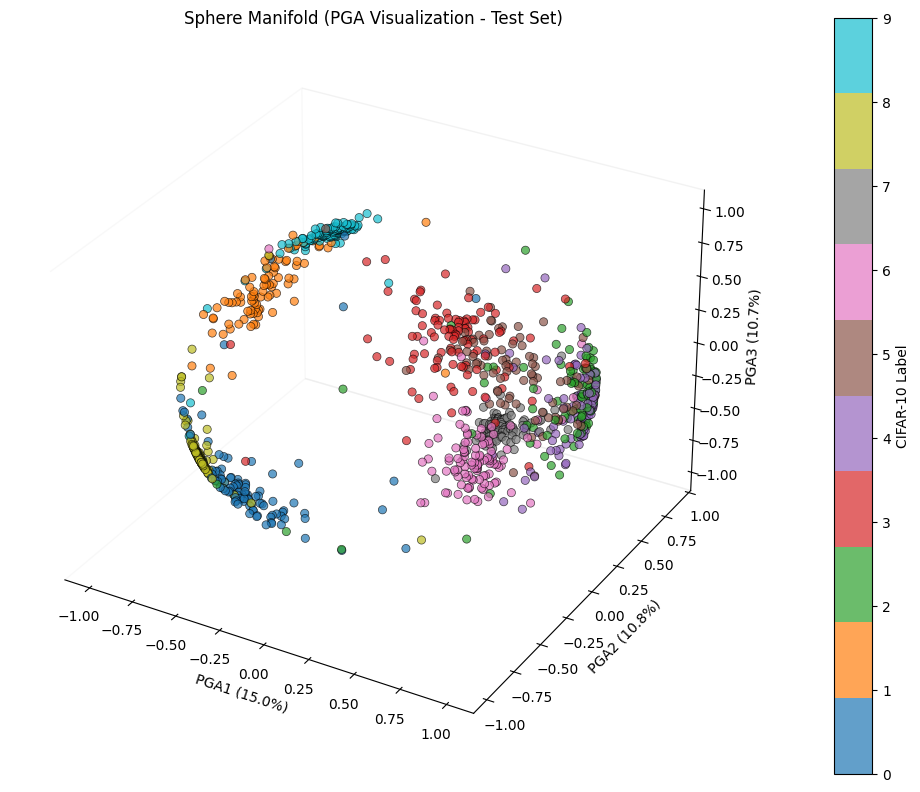


--- PHÂN TÍCH PHƯƠNG SAI PGA ---
Tổng phương sai được giữ lại (Top 3 PGA): 36.51%


In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import geoopt
from geoopt.manifolds.sphere import Sphere
import torch.nn.functional as F

print("\n--- TRÍCH XUẤT ĐẶC TRƯNG TỪ MÔ HÌNH ĐÃ HUẤN LUYỆN ---")
model.eval()
features_list = []
labels_list = []

# Chọn số lượng sample để vẽ (vẽ toàn bộ testset có thể làm nặng matplotlib)
num_viz_samples = 1000 
extracted_count = 0

with torch.no_grad():
    for images, targets in testloader:
        images = images.to(eval_device)
        
        # Trích xuất đặc trưng thô từ backbone
        raw_feat = model.backbone(images)
        
        # Chuẩn hóa L2 để đưa lên mặt cầu (giống bước xử lý trong forward)
        sphere_feat = F.normalize(raw_feat, p=2, dim=1, eps=1e-12)
        
        features_list.append(sphere_feat.cpu())
        labels_list.append(targets.cpu())
        
        extracted_count += images.size(0)
        if extracted_count >= num_viz_samples:
            break

# Ghép tensor và giới hạn đúng số lượng mẫu
sphere_features_cpu = torch.cat(features_list, dim=0)[:num_viz_samples]
viz_labels = torch.cat(labels_list, dim=0)[:num_viz_samples].numpy()

print(f"Đã trích xuất {sphere_features_cpu.shape[0]} mẫu. Đang chạy PGA...")

# ==========================================================
# PRINCIPAL GEODESIC ANALYSIS (PGA) TRÊN MẶT CẦU
# ==========================================================
sphere = Sphere()
sphere_points = sphere.projx(sphere_features_cpu.float())

# 1. Khởi tạo và tối ưu tìm Fréchet Mean bằng RiemannianAdam
mean_init = sphere.projx(sphere_points.mean(dim=0, keepdim=True))
frechet_mean = geoopt.ManifoldParameter(mean_init.clone(), manifold=sphere)
optimizer_pga = geoopt.optim.RiemannianAdam([frechet_mean], lr=0.05)

for _ in range(200):
    optimizer_pga.zero_grad()
    loss = sphere.dist(frechet_mean, sphere_points).square().mean()
    loss.backward()
    optimizer_pga.step()

frechet_mean = sphere.projx(frechet_mean.detach())

# 2. Chiếu dữ liệu xuống Tangent Space (Log Map)
base_point = frechet_mean.repeat(sphere_points.size(0), 1)
tangent_vectors = sphere.logmap(base_point, sphere_points)
tangent_vectors = sphere.proju(base_point, tangent_vectors)

# 3. PCA trên Tangent Space
_, singular_values, principal_directions = torch.pca_lowrank(
    tangent_vectors, q=3, center=True, niter=10
)
pga_3d = tangent_vectors @ principal_directions

# 4. Tính toán mức độ giải thích phương sai (Explained Variance Ratio)
tangent_centered = tangent_vectors - tangent_vectors.mean(dim=0, keepdim=True)
total_variance = tangent_centered.square().sum()
explained_ratio = (singular_values.square() / total_variance)

# Chuẩn hóa để vẽ đẹp trên mặt cầu 3D
pga_3d_sphere = F.normalize(pga_3d, dim=1)
pga_np = pga_3d_sphere.numpy()

# ==========================================================
# VẼ BIỂU ĐỒ 3D BẰNG MATPLOTLIB
# ==========================================================
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    pga_np[:, 0],
    pga_np[:, 1],
    pga_np[:, 2],
    c=viz_labels,
    cmap='tab10',
    alpha=0.7,
    s=35,
    edgecolors='k',
    linewidths=0.5
)

ax.set_title("Sphere Manifold (PGA Visualization - Test Set)")
ax.set_xlabel(f"PGA1 ({explained_ratio[0]*100:.1f}%)")
ax.set_ylabel(f"PGA2 ({explained_ratio[1]*100:.1f}%)")
ax.set_zlabel(f"PGA3 ({explained_ratio[2]*100:.1f}%)")

# Loại bỏ background grid để nhìn rõ cụm phân phối trên mặt cầu hơn
ax.grid(False)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

cbar = plt.colorbar(sc, ax=ax, label="CIFAR-10 Label", pad=0.1)
plt.tight_layout()
plt.show()

print("\n--- PHÂN TÍCH PHƯƠNG SAI PGA ---")
print(f"Tổng phương sai được giữ lại (Top 3 PGA): {(explained_ratio.sum().item() * 100):.2f}%")

In [22]:
%pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 6.2 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]2m1/2 [plotly]
Note: you may need to restart the kernel to use updated packages.


In [24]:
import numpy as np
import plotly.express as px
import pandas as pd

pga_3d_sphere = F.normalize(pga_3d, dim=1)
pga_np = pga_3d_sphere.numpy()

df = pd.DataFrame({
    "PGA1": pga_np[:, 0],
    "PGA2": pga_np[:, 1],
    "PGA3": pga_np[:, 2],
    "Label": viz_labels.astype(str)
})

# Tạo mặt cầu
u = np.linspace(0, 100*np.pi/50, 60)
v = np.linspace(0, np.pi, 60)

x = np.outer(np.cos(u), np.sin(v))
y = np.outer(np.sin(u), np.sin(v))
z = np.outer(np.ones_like(u), np.cos(v))

fig = px.scatter_3d(
    df,
    x="PGA1",
    y="PGA2",
    z="PGA3",
    color="Label",
    opacity=0.9
)

fig.add_surface(
    x=x,
    y=y,
    z=z,
    opacity=0.15,
    showscale=False,
    colorscale=[[0, "lightgray"], [1, "lightgray"]]
)

fig.update_layout(
    scene=dict(
        aspectmode="cube",
        xaxis=dict(range=[-1.0, 1.0]),
        yaxis=dict(range=[-1.0, 1.0]),
        zaxis=dict(range=[-1.0, 1.0]),
        xaxis_title=f"PGA1 ({explained_ratio[0]*100:.2f}%)",
        yaxis_title=f"PGA2 ({explained_ratio[1]*100:.2f}%)",
        zaxis_title=f"PGA3 ({explained_ratio[2]*100:.2f}%)",
        camera=dict(
            center=dict(x=0, y=0, z=0),
            eye=dict(x=1.2, y=1.2, z=1.2)
        )
    ),
    width=1100,
    height=900,
    title="Sphere Manifold with PGA Projection"
)

fig.show()